In [1]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
# https://numpy.org/doc/stable/reference/generated/numpy.moveaxis.html
# https://stackoverflow.com/questions/77265987/surface-fitting-python
# https://logicatcore.github.io/scratchpad/lidar/sensor-fusion/jupyter/2021/04/20/3D-Oriented-Bounding-Box.html

In [2]:
# import time
import logging
import numpy as np
from scipy import stats
from scipy.optimize import curve_fit
import pywt
import matplotlib.pyplot as plt
import skimage as ski
# import pyvista as pv
# import cv2 as cv
# import vtk
import glob

In [3]:
# fileLogOut = logging.FileHandler('rockProcessing.log', mode = 'w')
# consoleLogOut = logging.StreamHandler()
# logging.basicConfig(handlers = (fileLogOut, consoleLogOut), level = logging.INFO)
logging.basicConfig(filename='rockProcessing.log', level = logging.INFO)
logger = logging.getLogger('logger')

In [4]:
# Get slices:
CTSources = glob.glob('block_5/im6_shared/' + 'im_*[0-9].jp2')

In [5]:
# Sort slices
CTSources = sorted(CTSources)

In [6]:
# Reading images and moments calculation
CTImages = []
imagesMoments = []

for i in np.arange(0, len(CTSources), dtype = np.int64):
    CTImages.append(ski.io.imread(CTSources[i]))
    # CTImages.append(
    #     cv.imread(
    #         str(CTSources[i]),
    #         cv.IMREAD_GRAYSCALE
    #     )
    # )
    # imagesMoments.append(cv.moments(CTImages[-1]))
    imagesMoments.append(ski.measure.moments(CTImages[-1], order=0))
    logger.info(str(CTSources[i]))
    logger.info('\tHeight: ' + str(CTImages[i].shape[0]))
    logger.info('\tWidth: ' + str(CTImages[i].shape[1]))

In [7]:
# Convertion to numpy array
CTImages = np.array(CTImages)

In [8]:
# Slice for debugging
testSlice = 188

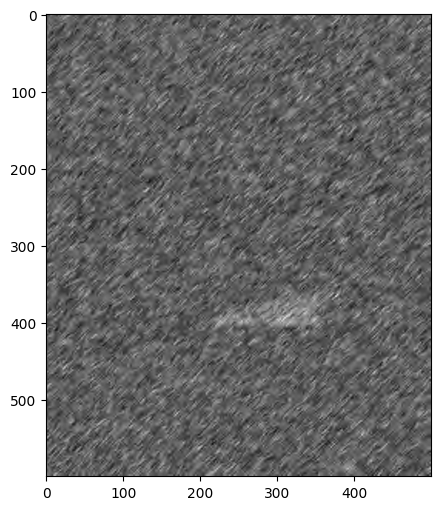

In [9]:
# Debugging
# Output original test slice
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(CTImages[testSlice], cmap=plt.cm.gray)

In [10]:
x = np.arange(0, len(CTImages))
# pk = np.array([imageMoment['m00'] for imageMoment in imagesMoments])
p = np.array([imageMoment[0][0] for imageMoment in imagesMoments])

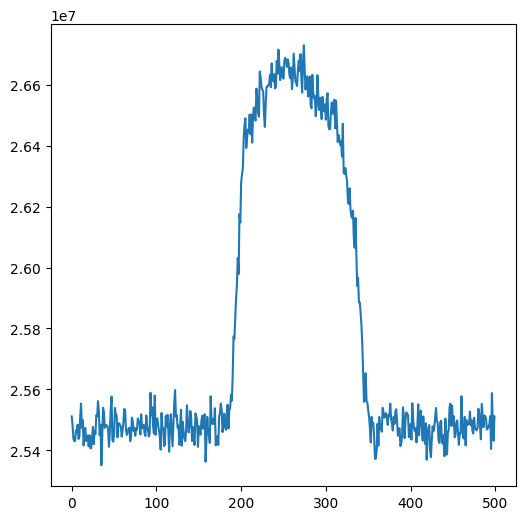

In [11]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)

In [12]:
# print(pywt.wavelist(kind='discrete'))

In [13]:
# print(pywt.Modes.modes)

In [14]:
p = p - np.min(p)
p = p/np.sum(p)

In [15]:
waveletType='db1'
DWTCoefficients = pywt.wavedec(p, waveletType, mode='periodic', level=4)

In [16]:
threshold = 1e-3
thresholdedDWTCoeffs = [pywt.threshold(coefficient, threshold, mode='soft') for coefficient in DWTCoefficients]

In [17]:
fp = pywt.waverec(thresholdedDWTCoeffs, waveletType, mode='periodic')

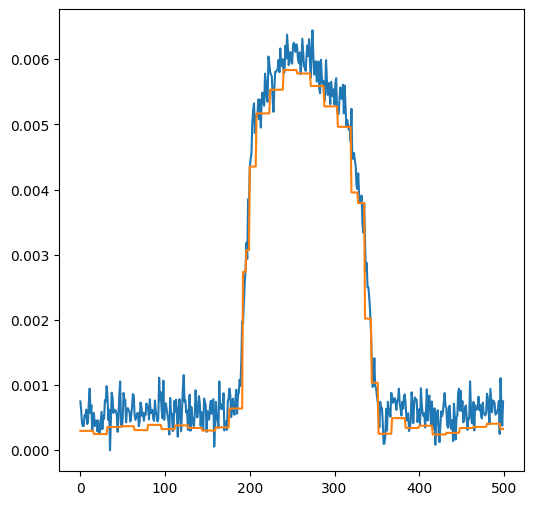

In [18]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)
axis.plot(x, fp)

In [19]:
fp = fp - np.min(fp)
fp = fp/np.sum(fp)

In [20]:
customDistribution =\
    stats.rv_discrete(
        name='customDistribution',
        values=(x, fp)
    )

In [21]:
stackRange = customDistribution.interval(0.95)

In [22]:
stackRange

(np.float64(182.0), np.float64(346.0))

In [23]:
offset = (12, 12)

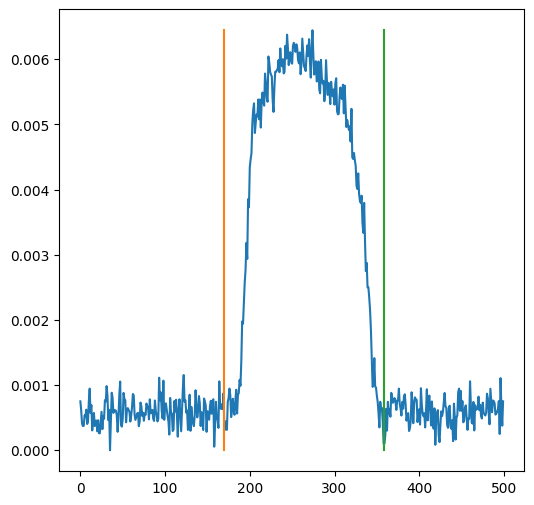

In [24]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)
# axis.plot(
#     [stackRange[0], stackRange[0]], [0, np.max(p)],
#     [stackRange[1], stackRange[1]], [0, np.max(p)]
# )
axis.plot(
    [stackRange[0] - offset[0], stackRange[0] - offset[0]], [0, np.max(p)],
    [stackRange[1] + offset[1], stackRange[1] + offset[1]], [0, np.max(p)]
)

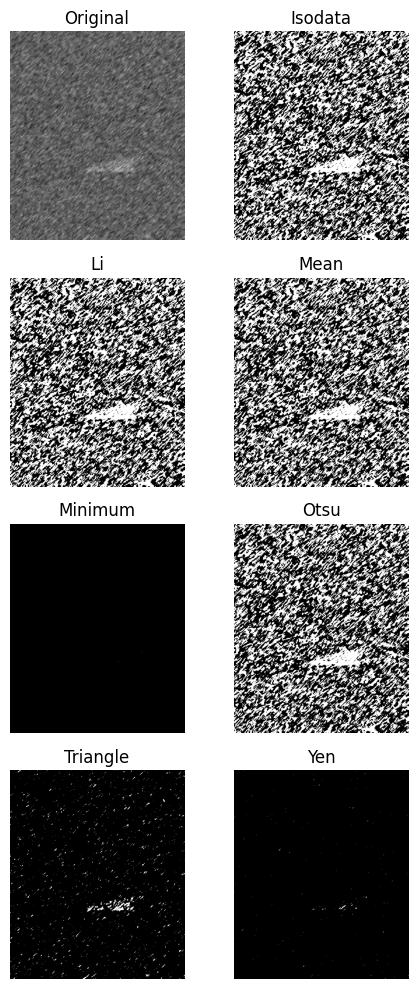

In [25]:
figure, axes = ski.filters.try_all_threshold(CTImages[testSlice], figsize=(5, 10), verbose=False)
plt.show()

In [26]:
entropy = ski.filters.rank.entropy(CTImages[testSlice], ski.morphology.disk(30))

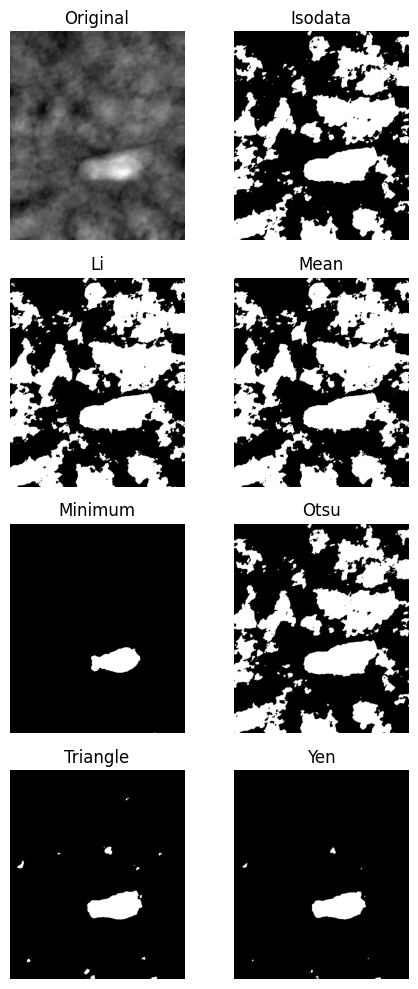

In [27]:
figure, axes = ski.filters.try_all_threshold(entropy, figsize=(5, 10), verbose=False)
plt.show()

In [28]:
# Find contours at a constant value
contours = ski.measure.find_contours(entropy, np.min(entropy) + 0.7*(np.max(entropy) - np.min(entropy)))

In [29]:
binaryImage = entropy > np.min(entropy) + 0.7*(np.max(entropy) - np.min(entropy))
hull = ski.morphology.convex_hull_image(binaryImage)

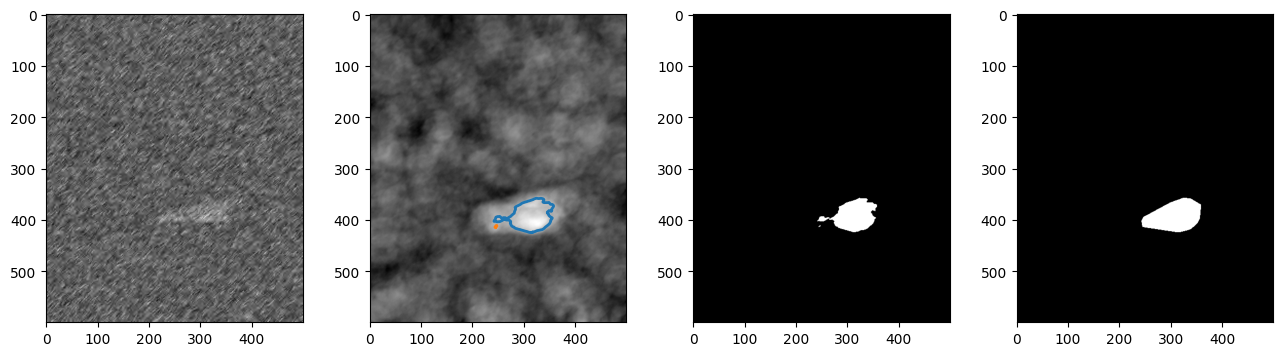

In [30]:
# Debugging
figure, axis = plt.subplots(nrows=1, ncols=4)
figure.set_size_inches(16, 4)
axis[0].imshow(CTImages[testSlice], cmap=plt.cm.gray)
axis[1].imshow(entropy, cmap=plt.cm.gray)
for contour in contours:
    axis[1].plot(contour[:, 1], contour[:, 0], linewidth=2)
axis[2].imshow(binaryImage, cmap=plt.cm.gray)
axis[3].imshow(hull, cmap=plt.cm.gray)

In [31]:
cumulativeHullZYX = np.zeros_like(CTImages[0], dtype=np.uint32)
binaryImagesZYX = []
entropyImagesZYX = []

for CTImage\
in\
CTImages[
    np.int32(np.max([stackRange[0] - offset[0], 0]))
    :
    np.int32(np.min([stackRange[1] + offset[1], len(CTImages) - 1]))
]:
    entropyImagesZYX.append(ski.filters.rank.entropy(CTImage, ski.morphology.disk(30)))
    minEntropy, maxEntropy = np.min(entropyImagesZYX[-1]), np.max(entropyImagesZYX[-1])
    binaryImagesZYX.append(entropyImagesZYX[-1] >= minEntropy + 0.7*(maxEntropy - minEntropy))
    cumulativeHullZYX += np.uint32(ski.morphology.convex_hull_image(binaryImagesZYX[-1]))

In [32]:
binaryImagesZYX = np.array(binaryImagesZYX)
entropyImagesZYX = np.array(entropyImagesZYX)

In [33]:
# entropyImages =\
#     np.array(
#         [
#             ski.filters.rank.entropy(CTImage, ski.morphology.disk(30))\
#             for CTImage in CTImages[int(stackRange[0]):int(stackRange[1])]
#         ]
#     )
# minEntropy, maxEntropy = np.min(entropyImages), np.max(entropyImages)

In [34]:
# cumulativeHull = np.zeros_like(CTImages[0], dtype=np.uint32)

# for entropyImage in entropyImages:
#     binaryImage = entropyImage >= minEntropy + 0.5*(maxEntropy - minEntropy)
#     cumulativeHull += np.uint32(ski.morphology.convex_hull_image(binaryImage))

In [54]:
binaryImage = cumulativeHullZYX >= np.int32(0.5*(stackRange[1] - stackRange[0]))
labeledImage = ski.measure.label(binaryImage)
region = ski.measure.regionprops(labeledImage)[0]

In [55]:
rotatedImage =\
    ski.transform.rotate(
        cumulativeHullZYX,
        angle=-region.orientation*180.0/np.pi,
        center=region.centroid,
        resize=False
    )

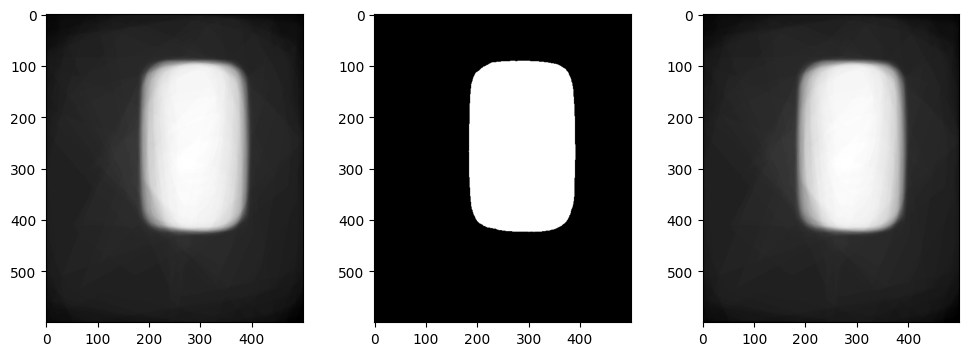

In [56]:
# Debugging
figure, axis = plt.subplots(nrows=1, ncols=3)
figure.set_size_inches(12, 4)
axis[0].imshow(cumulativeHullZYX, cmap=plt.cm.gray)
axis[1].imshow(binaryImage, cmap=plt.cm.gray)
axis[2].imshow(rotatedImage, cmap=plt.cm.gray)

In [59]:
CTImages.shape

(500, 600, 500)

In [ ]:
binaryImagesZYX = np.moveaxis(binaryImagesZYX, 0, -1)
entropyImagesZYX = np.moveaxis(entropyImagesZYX, 0, -1)